Calculations and figure for FINESST

In [1]:
import numpy as np
import cosmo_calc as cc
from astropy import units as u
from matplotlib import pyplot as plt
import matplotlib as mpl
import importlib
from matplotlib.ticker import MaxNLocator

# Turn k into halo mass

Equation 2 from Bullock & Boylan-Kolchin, 17: \
$$M_l = \frac{4\pi}{3}r^3_l\rho_m$$
Other relevant equations: \
$$r_l = \pi/k$$
$$\rho_m = \frac{3H_0^2}{8\pi G}*\Omega_M$$

In [2]:
z = 0

In [3]:
cosmo = cc.classy_cosmology()

In [6]:
def calc_rho_m(cosmo, z):
    c = 3e8*u.m/u.s # speed of light
    H0 = (cosmo.Hubble(z)/u.Mpc*c) # H0 comes divided by c by default, so we have to take that out
    G = 6.67430e-11* u.m**3 * u.s**-2 * u.kg**-1

    rho_crit_0 = ((3*H0**2)/(8*np.pi*G)).to(u.Msun/u.Mpc**3)

    return (cosmo.Omega_m()*rho_crit_0)

In [7]:
rho_m = calc_rho_m(cosmo, z)

In [8]:
def k_to_M(k, rho_m):
    r_l = np.pi/k
    return 4*np.pi/3 * r_l**3 * rho_m

In [9]:
k_to_M(0.5*u.Mpc**-1, rho_m)

<Quantity 4.12410272e+13 solMass>

In [10]:
k_to_M(10*u.Mpc**-1, rho_m)

<Quantity 5.1551284e+09 solMass>

# Modify Sabti+ fig. 1

In [11]:
mpl.rc('text', usetex=True)
mpl.rcParams['text.latex.preamble']=r"\usepackage{amsmath}"

# Get the curve that defines the non-linear regime
nonlinear = np.loadtxt("/Users/eb35267/Desktop/research/GALLUMI_public/Scripts/Plotting/All_probes/nonlinear.txt", unpack=True)

FileNotFoundError: /Users/eb35267/Desktop/research/GALLUMI_public/Scripts/Plotting/All_probes/nonlinear.txt not found.

In [5]:
edge_color = '#294450'
my_face_color = '#b84557ff'
my_edge_color = '#8d2536'
nl_color = '#8aa0ff'
divergence_color = '#719920'
small_font_size = 17
patch_alpha = .3

In [4]:
rhoM = 2.77463e11 * 0.7**2 * 0.3

<span style='color:red'>Future: figure should be reoriented so that masses increase on the left vertical axis <span>

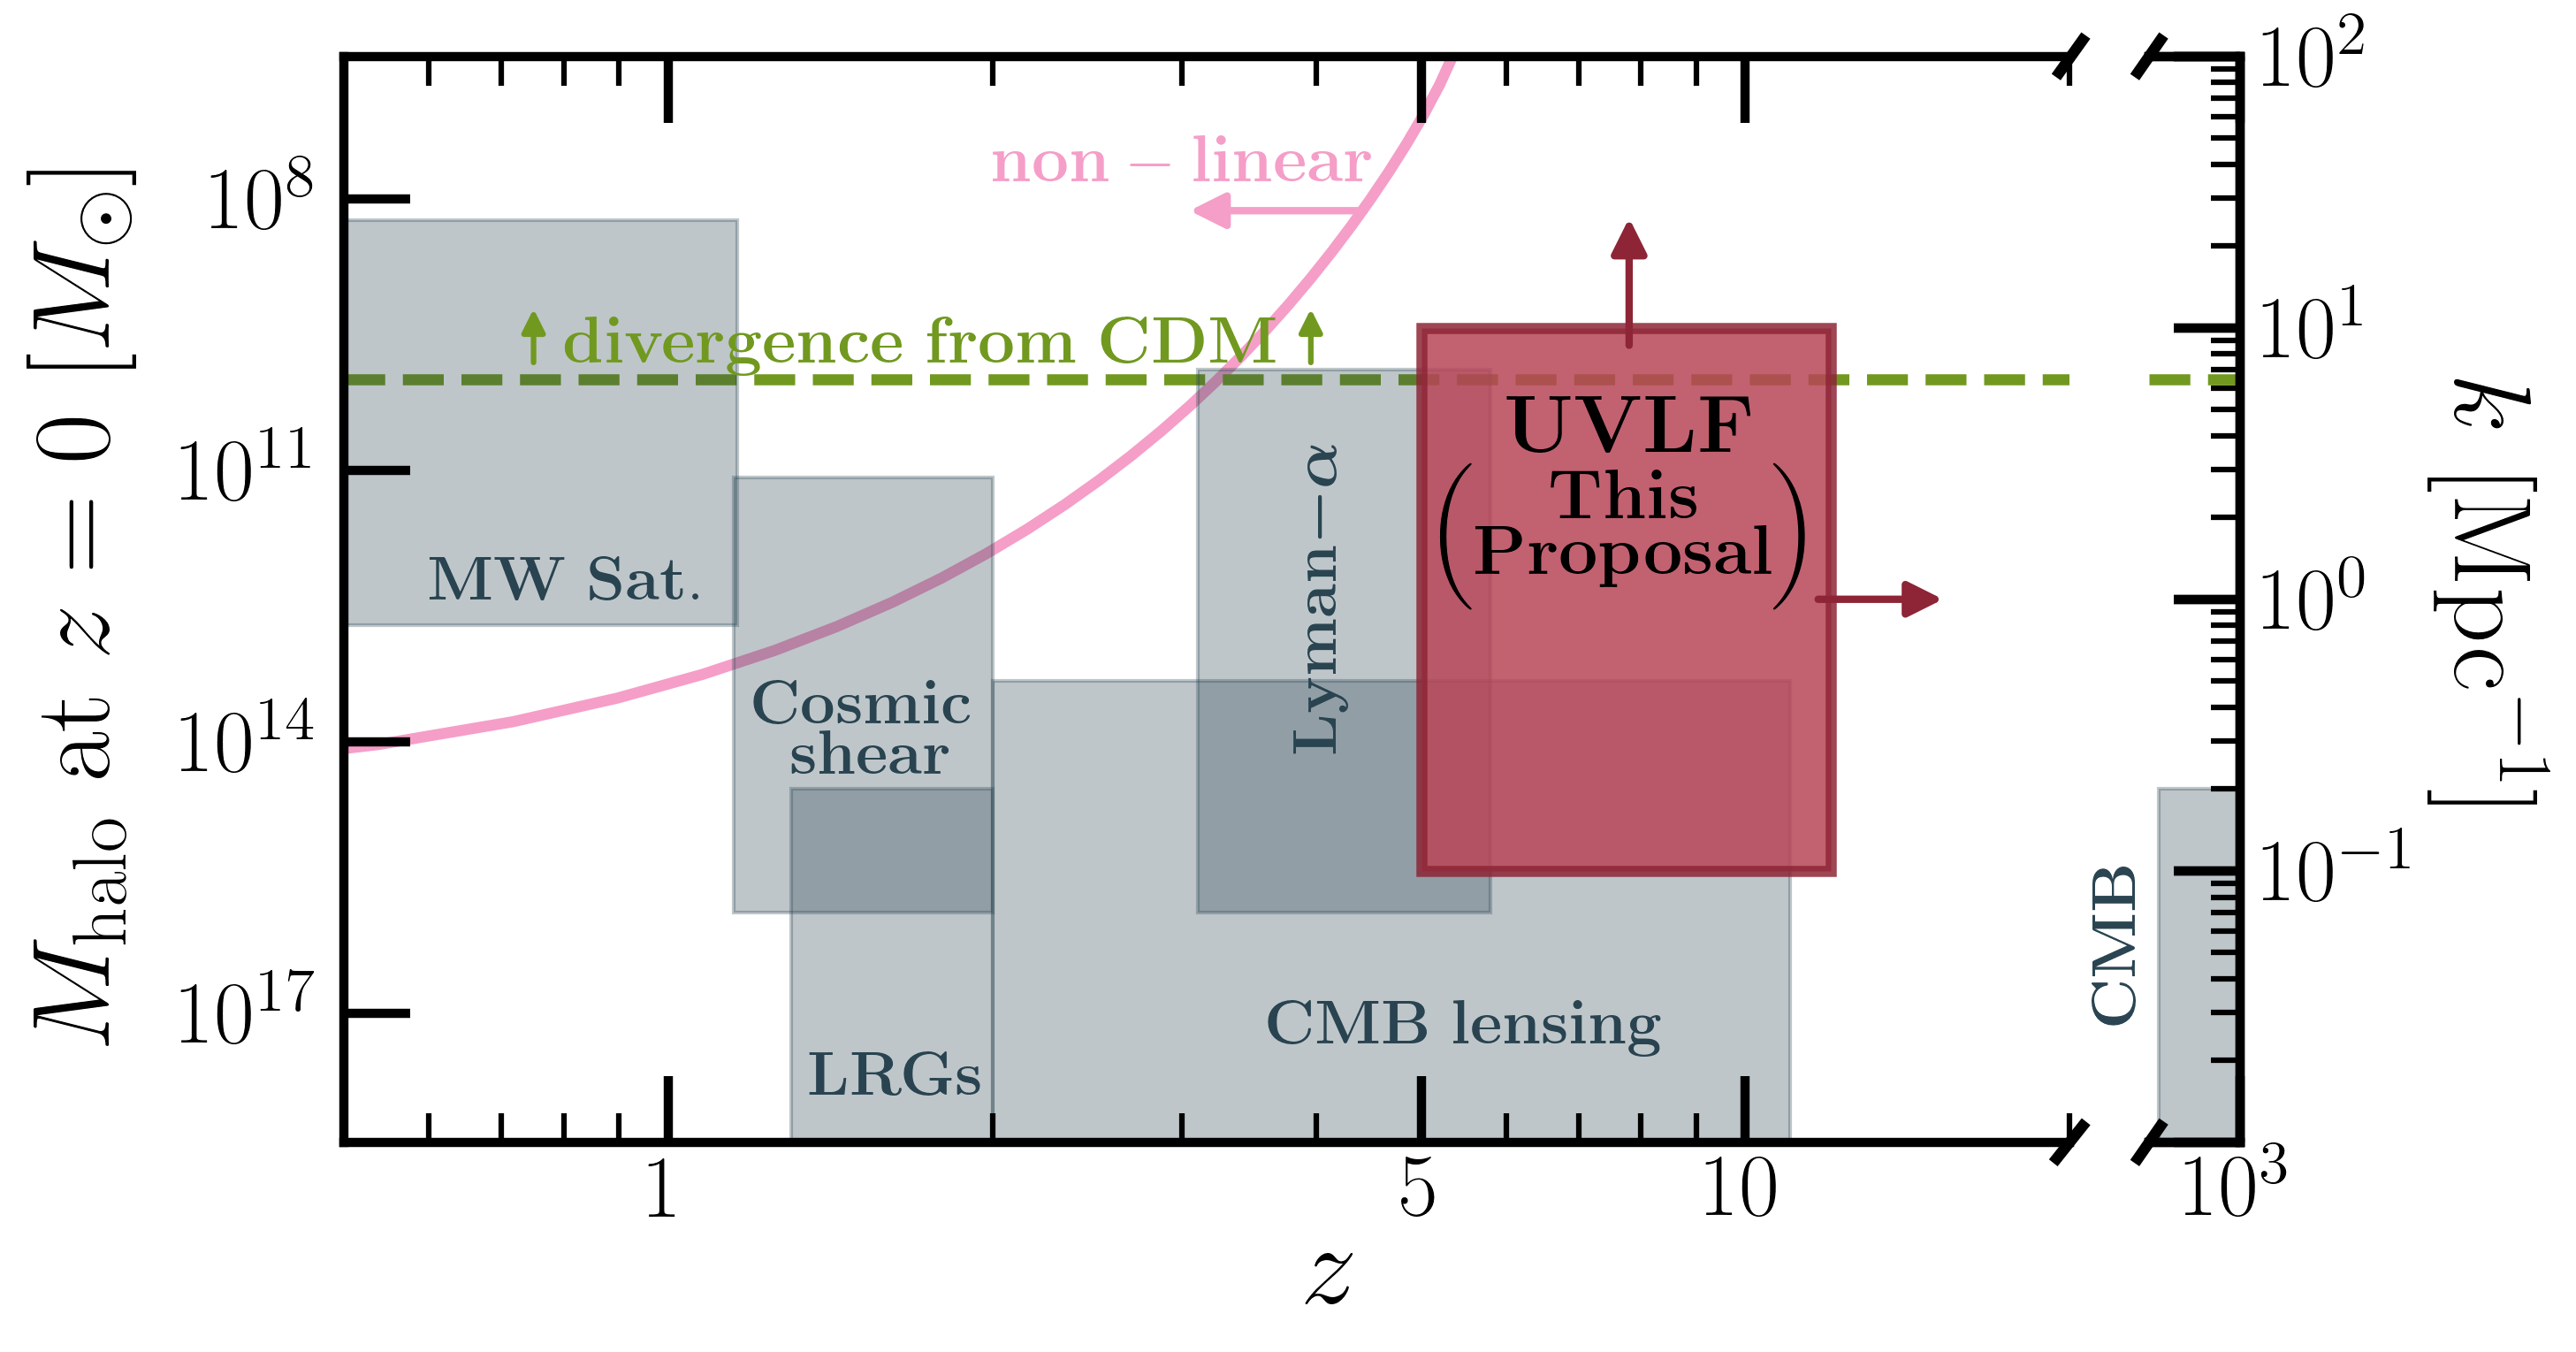

In [8]:
fig = plt.figure(figsize=(8,5), facecolor='white')

rhoM = 2.77463e11 * 0.7**2 * 0.3

left_margin = 0.6 / fig.get_figwidth()
right_margin = 0.25 / fig.get_figwidth()
bottom_margin = 0.75 / fig.get_figheight()
top_margin = 0.25 / fig.get_figwidth()
mid_margin = 0.3 / fig.get_figwidth()  
f = [0.95, 0.05]
Naxes = len(f)
x0, y0 = left_margin, bottom_margin
h = 1 - (bottom_margin + top_margin)
wtot = 1 - (left_margin + right_margin + (Naxes-1)*mid_margin)
w = wtot*f[0]
ax = fig.add_axes([x0, y0, w, h], frameon=True, facecolor='none')
x0 += w + mid_margin
w = wtot*f[1]
ax2 = fig.add_axes([x0, y0, w, h], frameon=True, facecolor='none')
x0 += w + mid_margin

ax.set_xlim(0.5, 20.) # Change this because we're not plotting 21-cm anymore
ax.set_ylim(1e-2, 1e2) 
ax2.set_xlim(900, 1000.)
ax2.set_ylim(1e-2, 1e2) 
ax3 = ax2.twinx()
ax3.set_ylim(1e-2, 1e2) 

# These settings regulate the break in the x-axis
ax.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax.yaxis.tick_left()
ax2.yaxis.tick_right()
ax2.tick_params(axis='x', which='minor', bottom=False, top=False)
ax2.tick_params(axis='y', which='both', labelright=False)
ax3.spines['left'].set_visible(False)
ax3.yaxis.tick_right()

ax3.set_ylabel(r'$k\ [\mathrm{Mpc}^{-1}]$', rotation=-90)
ax3.set_yscale('log')
# These two remove minor ticks on the left y-axis
ax3.tick_params(axis='y', which='minor', left=False, right=False) 
ax.tick_params(axis='y', which='minor',length=0, zorder = 10)

ax.set_ylabel(r'$M_\mathrm{halo}\ \mathrm{at}\ z = 0\ [M_\odot]$', labelpad=12)
ax.set_xlabel(r'$z$', fontsize=31, va='center', ha='center')
ax.xaxis.set_label_coords(0.54, .05, transform=fig.transFigure) # This makes x-axis look visually centered

# These are the two // that denote the jump in z
d = .015
kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
ax.plot((1-d/2,1+d/2), (-d,+d), **kwargs) # Subtract one because the original was 1+z
ax.plot((1-d/2.5,1+d/2),(1-d,1+d), **kwargs)
d = .015
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d*8.3,+d*8.3), (1-d,1+d), **kwargs)
ax2.plot((-d*8.3,+d*8.3), (-d,+d), **kwargs)

# Non-linear
ax.plot(nonlinear[0] - 1, nonlinear[1], color=nl_color,zorder=0) # Subtract one because the original had 1+z on the x-axis
ax.annotate(text='', xytext=(4.5, 27), xy=(3, 27), arrowprops={'arrowstyle': '-|>', 'color': nl_color, 'lw':2, 'mutation_scale':20}, 
            color=nl_color)
ax.text(2, 35, r'$\mathbf{non-linear}$', fontsize=18, color=nl_color)

# Divergence
ax2.axhline(y = 1/(np.power(3. * 1e10 / (4. * np.pi * rhoM), 1./3) / 2.5), color = divergence_color, linestyle = '--', zorder = 0)
ax.axhline(y = 1/(np.power(3. * 1e10 / (4. * np.pi * rhoM), 1./3) / 2.5), color = divergence_color, linestyle = '--', zorder = 0)
ax.annotate(text='', xytext=(.75, 7), xy=(.75, 12.5), arrowprops={'arrowstyle': '-|>', 'color': divergence_color, 'lw': 1.5, 
                                                              'mutation_scale': 13}, color=divergence_color)
ax.annotate(text='', xytext=(3.95, 7), xy=(3.95, 12.5), arrowprops={'arrowstyle': '-|>', 'color': divergence_color, 'lw': 1.5, 
                                                              'mutation_scale': 13}, color=divergence_color)
ax.text(.8, 7.5, r'$\mathbf{divergence\ from\ CDM}$', fontsize=18, color=divergence_color, zorder = 4)

# Patches
ax.add_patch(plt.Rectangle(xy=(1e-2, 0.8), width=1.15, height=25-0.8, facecolor=edge_color, edgecolor = edge_color, alpha = patch_alpha, 
                           zorder=1))
ax.add_patch(plt.Rectangle(xy=(1.15, 0.07), width=0.85, height=2.8-0.07, facecolor=edge_color, edgecolor = edge_color, alpha = patch_alpha, 
                           zorder=2))
ax.add_patch(plt.Rectangle(xy=(1.3, 0.01), width=0.7, height=0.2-0.01, facecolor=edge_color, edgecolor = edge_color, alpha = patch_alpha, 
                           zorder=1))
ax.add_patch(plt.Rectangle(xy=(2., 0.01), width=9., height=0.5-0.01, facecolor=edge_color, edgecolor = edge_color, alpha = patch_alpha, 
                           zorder=1))
ax.add_patch(plt.Rectangle(xy=(3.1, 0.07), width=2.7, height=7.-0.07, facecolor=edge_color, edgecolor = edge_color, alpha = patch_alpha, 
                           zorder=1))
ax.add_patch(plt.Rectangle(xy=(5, 0.1), width=7, height=10.-0.1, facecolor=my_face_color, linewidth=3, alpha = .85, edgecolor=my_edge_color, zorder=3))
ax2.add_patch(plt.Rectangle(xy=(910, 0.01), width=90, height=0.2-0.01, color=edge_color, alpha = patch_alpha, zorder=1))
# Arrows pointing up and to the right from the proposal rectangle
ax.annotate(text='', xytext=(11.5, 1), xy=(15.5, 1), arrowprops={'arrowstyle': '-|>', 'color': my_edge_color, 'mutation_scale': 20,
                                                               'lw':2}, color=my_edge_color)
ax.annotate(text='', xytext=(7.8, 8.1), xy=(7.8, 27), arrowprops={'arrowstyle': '-|>', 'color': my_edge_color, 'mutation_scale': 20,
                                                                  'lw':2}, color=my_edge_color)
# Remove 21-cm: 
# ax.add_patch(plt.Rectangle(xy=(6., 1.), width=24., height=50.-1., color=np.array([0., 0., 0., 0.25]), zorder=1))

ax.text(0.6, 1, r'$\mathbf{MW\ Sat.}$', fontsize=small_font_size, color=edge_color)
ax.text(1.2, 0.35, r'$\mathbf{Cosmic}$', fontsize=small_font_size, color=edge_color)
ax.text(1.3, 0.23, r'$\mathbf{shear}$', fontsize=small_font_size, color=edge_color)
ax.text(1.35, 0.015, r'$\mathbf{LRGs}$', fontsize=small_font_size, color=edge_color)
ax.text(3.6, 0.023, r'$\mathbf{CMB\ lensing}$', fontsize=small_font_size, color=edge_color)
ax.text(3.8, 0.3, r'$\mathbf{Lyman}\boldsymbol{-\alpha}$', fontsize=small_font_size, rotation=90, color=edge_color)
ax.text(6, 3.5, r'$\mathbf{UVLF}$', fontsize=22, color='k')
ax.text(6.6, 2, r'$\mathbf{This}$', fontsize=19, color='k')
ax.text(5.6, 1.25, r'$\mathbf{Proposal}$', fontsize=19, color='k')
ax.text(5.2, 1.25, r'$\mathbf{(}$', fontsize=40, color='k')
ax.text(10.6, 1.25, r'$\mathbf{)}$', fontsize=40, color='k')
ax.text(21, 0.03, r'$\mathbf{CMB}$', fontsize=small_font_size, rotation=90, color=edge_color)
# Remove 21-cm:
# ax.text(16.2, 1.25, r'$\mathbf{21\hspace{-2mm}\boldsymbol{-}\hspace{-2mm}cm}$', fontsize=22, color=np.array([0,0,0, 0.6]))

ax.semilogy()
ax.semilogx()
ax2.semilogy()
ax2.semilogx()
ax.set_xticks([1., 5., 10.])
ax.set_xticklabels([r'$1$', r'$5$', r'$10$'])
Mhs = np.array([1e8, 1e11, 1e14, 1e17])
ks = 1/(np.power(3. * Mhs / (4. * np.pi * rhoM), 1./3) / 2.5)
ax.set_yticks([ks[0], ks[1], ks[2], ks[3]])
ax.set_yticklabels([r'$10^{8}$', r'$10^{11}$', r'$10^{14}$', r'$10^{17}$'])
ax3.set_yticks(np.logspace(-1, 2, 4))

#plt.savefig('/Users/eb35267/Desktop/figures/FINESST/DM_regimes.pdf', bbox_inches = 'tight')

#b84557
#03abc1
#d4d000
#294450
#c15c25
#719920
#f59ec8


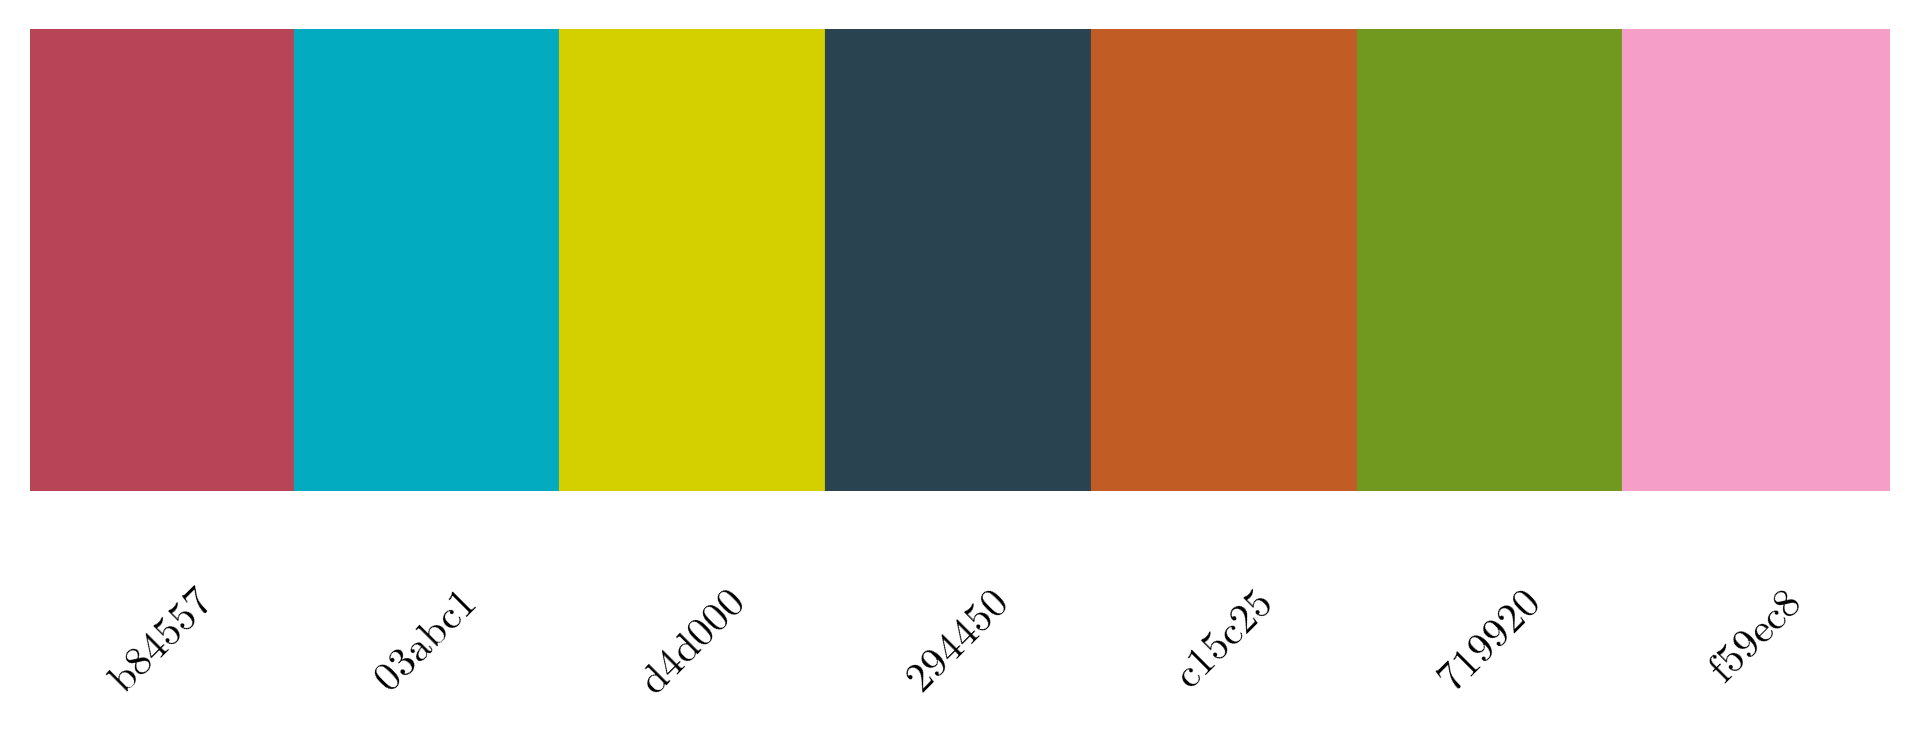

In [35]:
plot_colors()

In [24]:
def plot_colors():
    # Get the default color cycle from rcParams
    color_cycler = mpl.rcParams['axes.prop_cycle']
    colors = [c['color'] for c in color_cycler]
    
    # Create a figure to visualize the colors
    fig, ax = plt.subplots(figsize=(8, 2))
    ax.set_xlim(0, len(colors))
    ax.set_ylim(0, 1)
    
    # Plot each color as a rectangle
    for i, color in enumerate(colors):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
        hex_color = mpl.colors.to_hex(color)
        ax.text(i + 0.5, -0.2, hex_color.replace("#", ""),  # Remove '#' symbol
            ha='center', va='top', fontsize=10, color='black', rotation=45)
        print(hex_color)
    
    # Formatting
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    
    plt.show()
    return